In [1]:
#from IPython.display import display, Latex

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Program implementation (reference, dimmer case site dots)

Under tight binding formulation using second quantization we have the following stuff for the central part:

$$
H_{cen}= \sum_{i}^{2} \vec{c_{i}}^{\dagger} \hat{\epsilon}^{0}_{i} \vec{c_{i}} + \vec{a_{i}}^{\dagger} \hat{\epsilon}^{1}_{i} \vec{a_{i}} + \sum_{i}^{2} \vec{c_{i}}^{\dagger} \hat{\omega} \vec{a_{i}} + h.c. + \sum_{i}^{1} \vec{c_{i}}^{\dagger} \hat{V} \vec{c}_{i+1}+h.c.
$$

Renormalizing the lateral dot sites energies in a new basis, e.g. $\hat{d}_{i}(\hat{d}^{\dagger}_{i})$, we obtain the following:

$$
H_{cen}= \sum_{i}^{2} \vec{d_{i}}^{\dagger} \hat{\varepsilon}_{i} \vec{d_{i}} + \sum_{i}^{1} \vec{d_{i}}^{\dagger} \hat{V} \vec{d}_{i+1}+h.c.
$$

where:

$$
\varepsilon_{i} = \epsilon^{0}_{i} + \frac{\omega^{2}}{E-\epsilon^{1}_{i}}
$$

By assumption we set $\epsilon^{1}_{i}\neq0$ and $\omega\neq0$

## Numerical definition of the functions

For consistent calculations is recommended set the following units and orders of magnitude:
 
$E \sim \epsilon^{\sigma}_{i} \sim 10^{0}=1\,meV$

**Also, the functions havo to include the polarization as parameter because of the parametrization of the spin dependenti gamma constant ($\gamma^{\sigma}$)**

In [2]:
import functions_spin_p as fy
from importlib import reload

reload(fy)

<module 'functions_spin_p' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots/functions_spin_p.py'>

# Aplication:

### Quantum Interference analysis for $T_{\sigma}(E)$

For the 2 dimensional case which is an horizontal toy model (now including spin dependence), the Landauer Transmission function will not have energy antiresonances, so, ther will not be Fano Resonances!



### Example: Spin dependent Transmission plot

**Important:** If the location of any of the energies resonances is not match with the Transmission Plot (only in the y-axis) but it matches only with the x-axis. So, the Plot is correct, however, it is needed increase the numerical precision (by decreasing the step size in the energy_axis)

# Toy Model:

**Fixed parameters**

$\epsilon^{0}_{1}\,=\,\epsilon^{0}_{2}\,=\,0\,meV$ 

$\epsilon^{1}_{1}\,=\epsilon^{0}_{1}\,=\,2\,meV$ 

$\gamma\,=\,1\,meV$

$E\,=\,[-6,6]$ $meV$

# Varying the Hopping V:

**Fixed parameter**

$\omega\,=\,\,0\,meV$

In [3]:
#Energy axis

energy_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 1 #meV
print("The width is:",gamma,"meV")

#Hopping parameter:
om = 0 #meV

#Site energies:
e_01 = 0 #meV
e_02 = 0 #meV
e_11 = 2 #meV
e_12 = 2 #meV

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

print("The site (spin independent) energies to be renormalized are:", \
       e_ren_1," meV and",e_ren_2," meV")

Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV
The width is: 1 meV
The site (spin independent) energies to be renormalized are: [0 2 0]  meV and [0 2 0]  meV


## Reference case:

We have $V=0.5$. Additionally, if $p_{L(R)}=0$ we have the same width (i.e. same particle lifetime) per spin channel! 

Additional, we include the different polarization configurations

**Nota: el grafico da una transmision nula, repito, no es un problema de Zoom o de resolucion**

In [4]:
# Hopping
v = 0.5 #meV

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j]]


In [5]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots/functions_spin_p.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  transmission_axis_up[i] = green_matrix(energy_array[i], gamma_parameter, H, sites, polarization_left, polarization_right)[0]
/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_model/site_dots/functions_spin_p.py:101: ComplexWarning: Casting complex values to real discards the imaginary part
  transmission_axis_down[i] = green_matrix(energy_array[i], gamma_parameter, H, sites, polarization_left, polarization_right)[1]


In [6]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [7]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:118: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


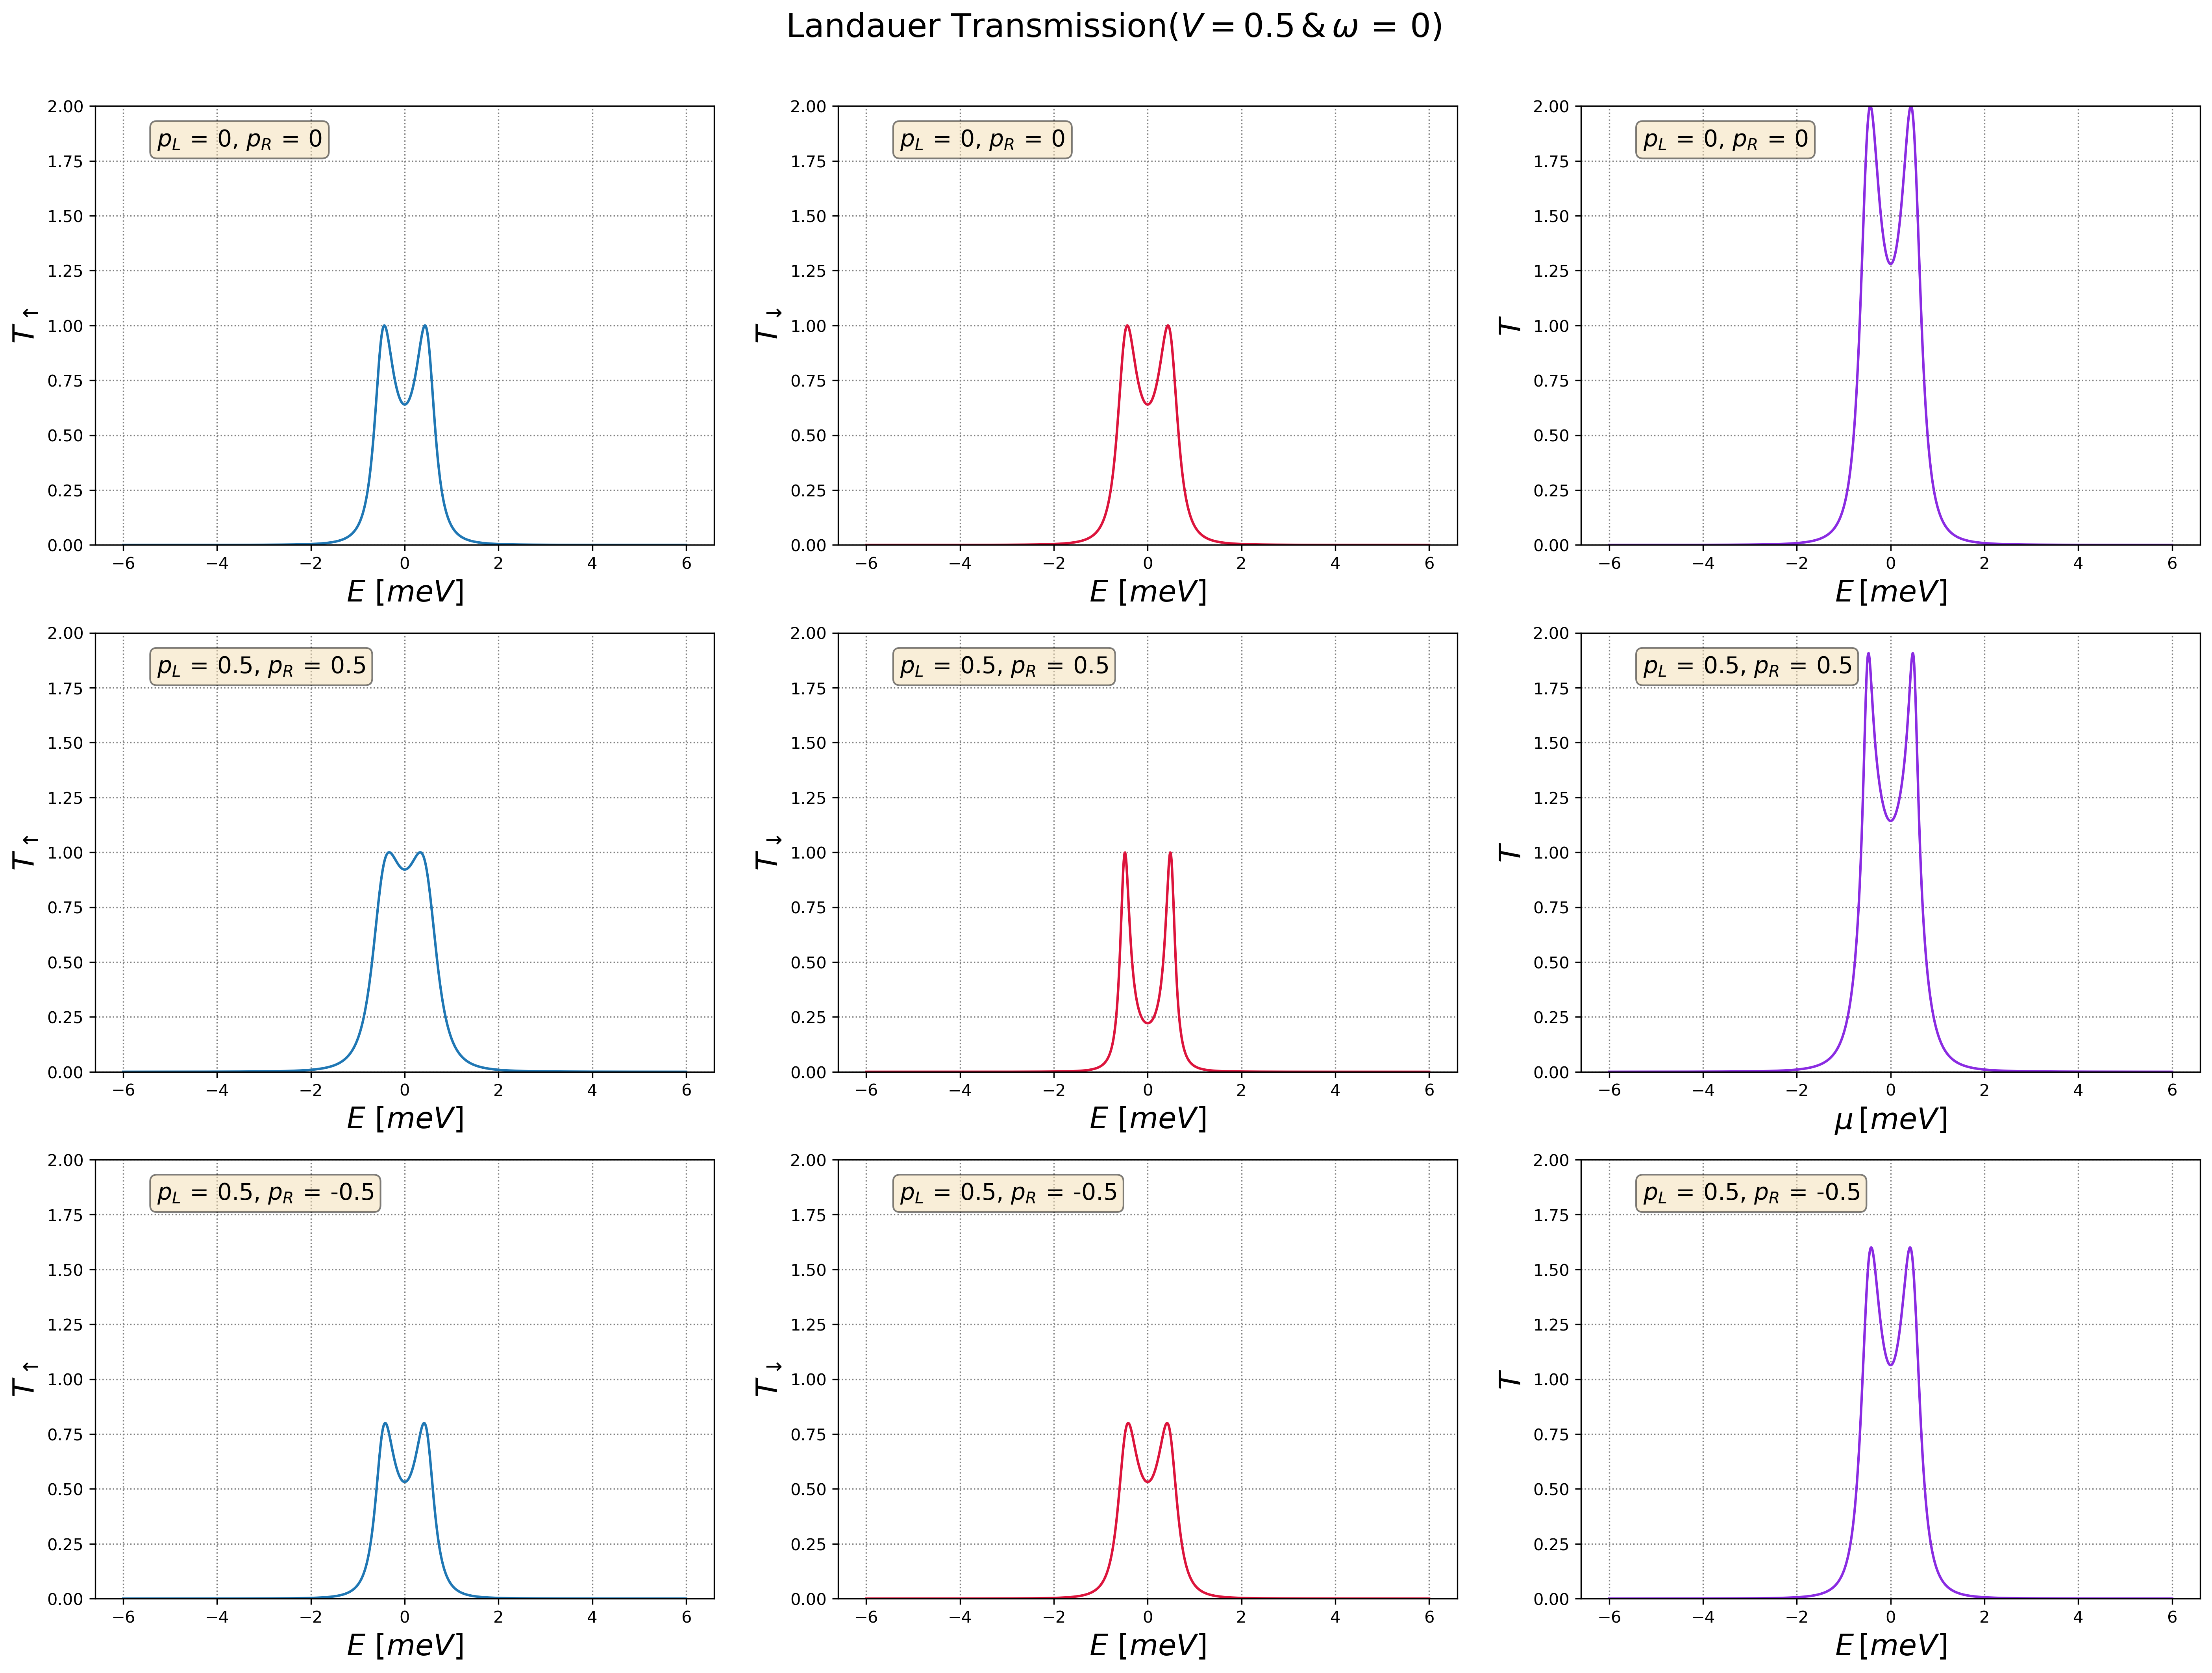

In [8]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('Reference.jpg')

## Case 1: $V=1$ and for different polarization configurations

In [9]:
# Hopping
v = 1

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [10]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [11]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [12]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


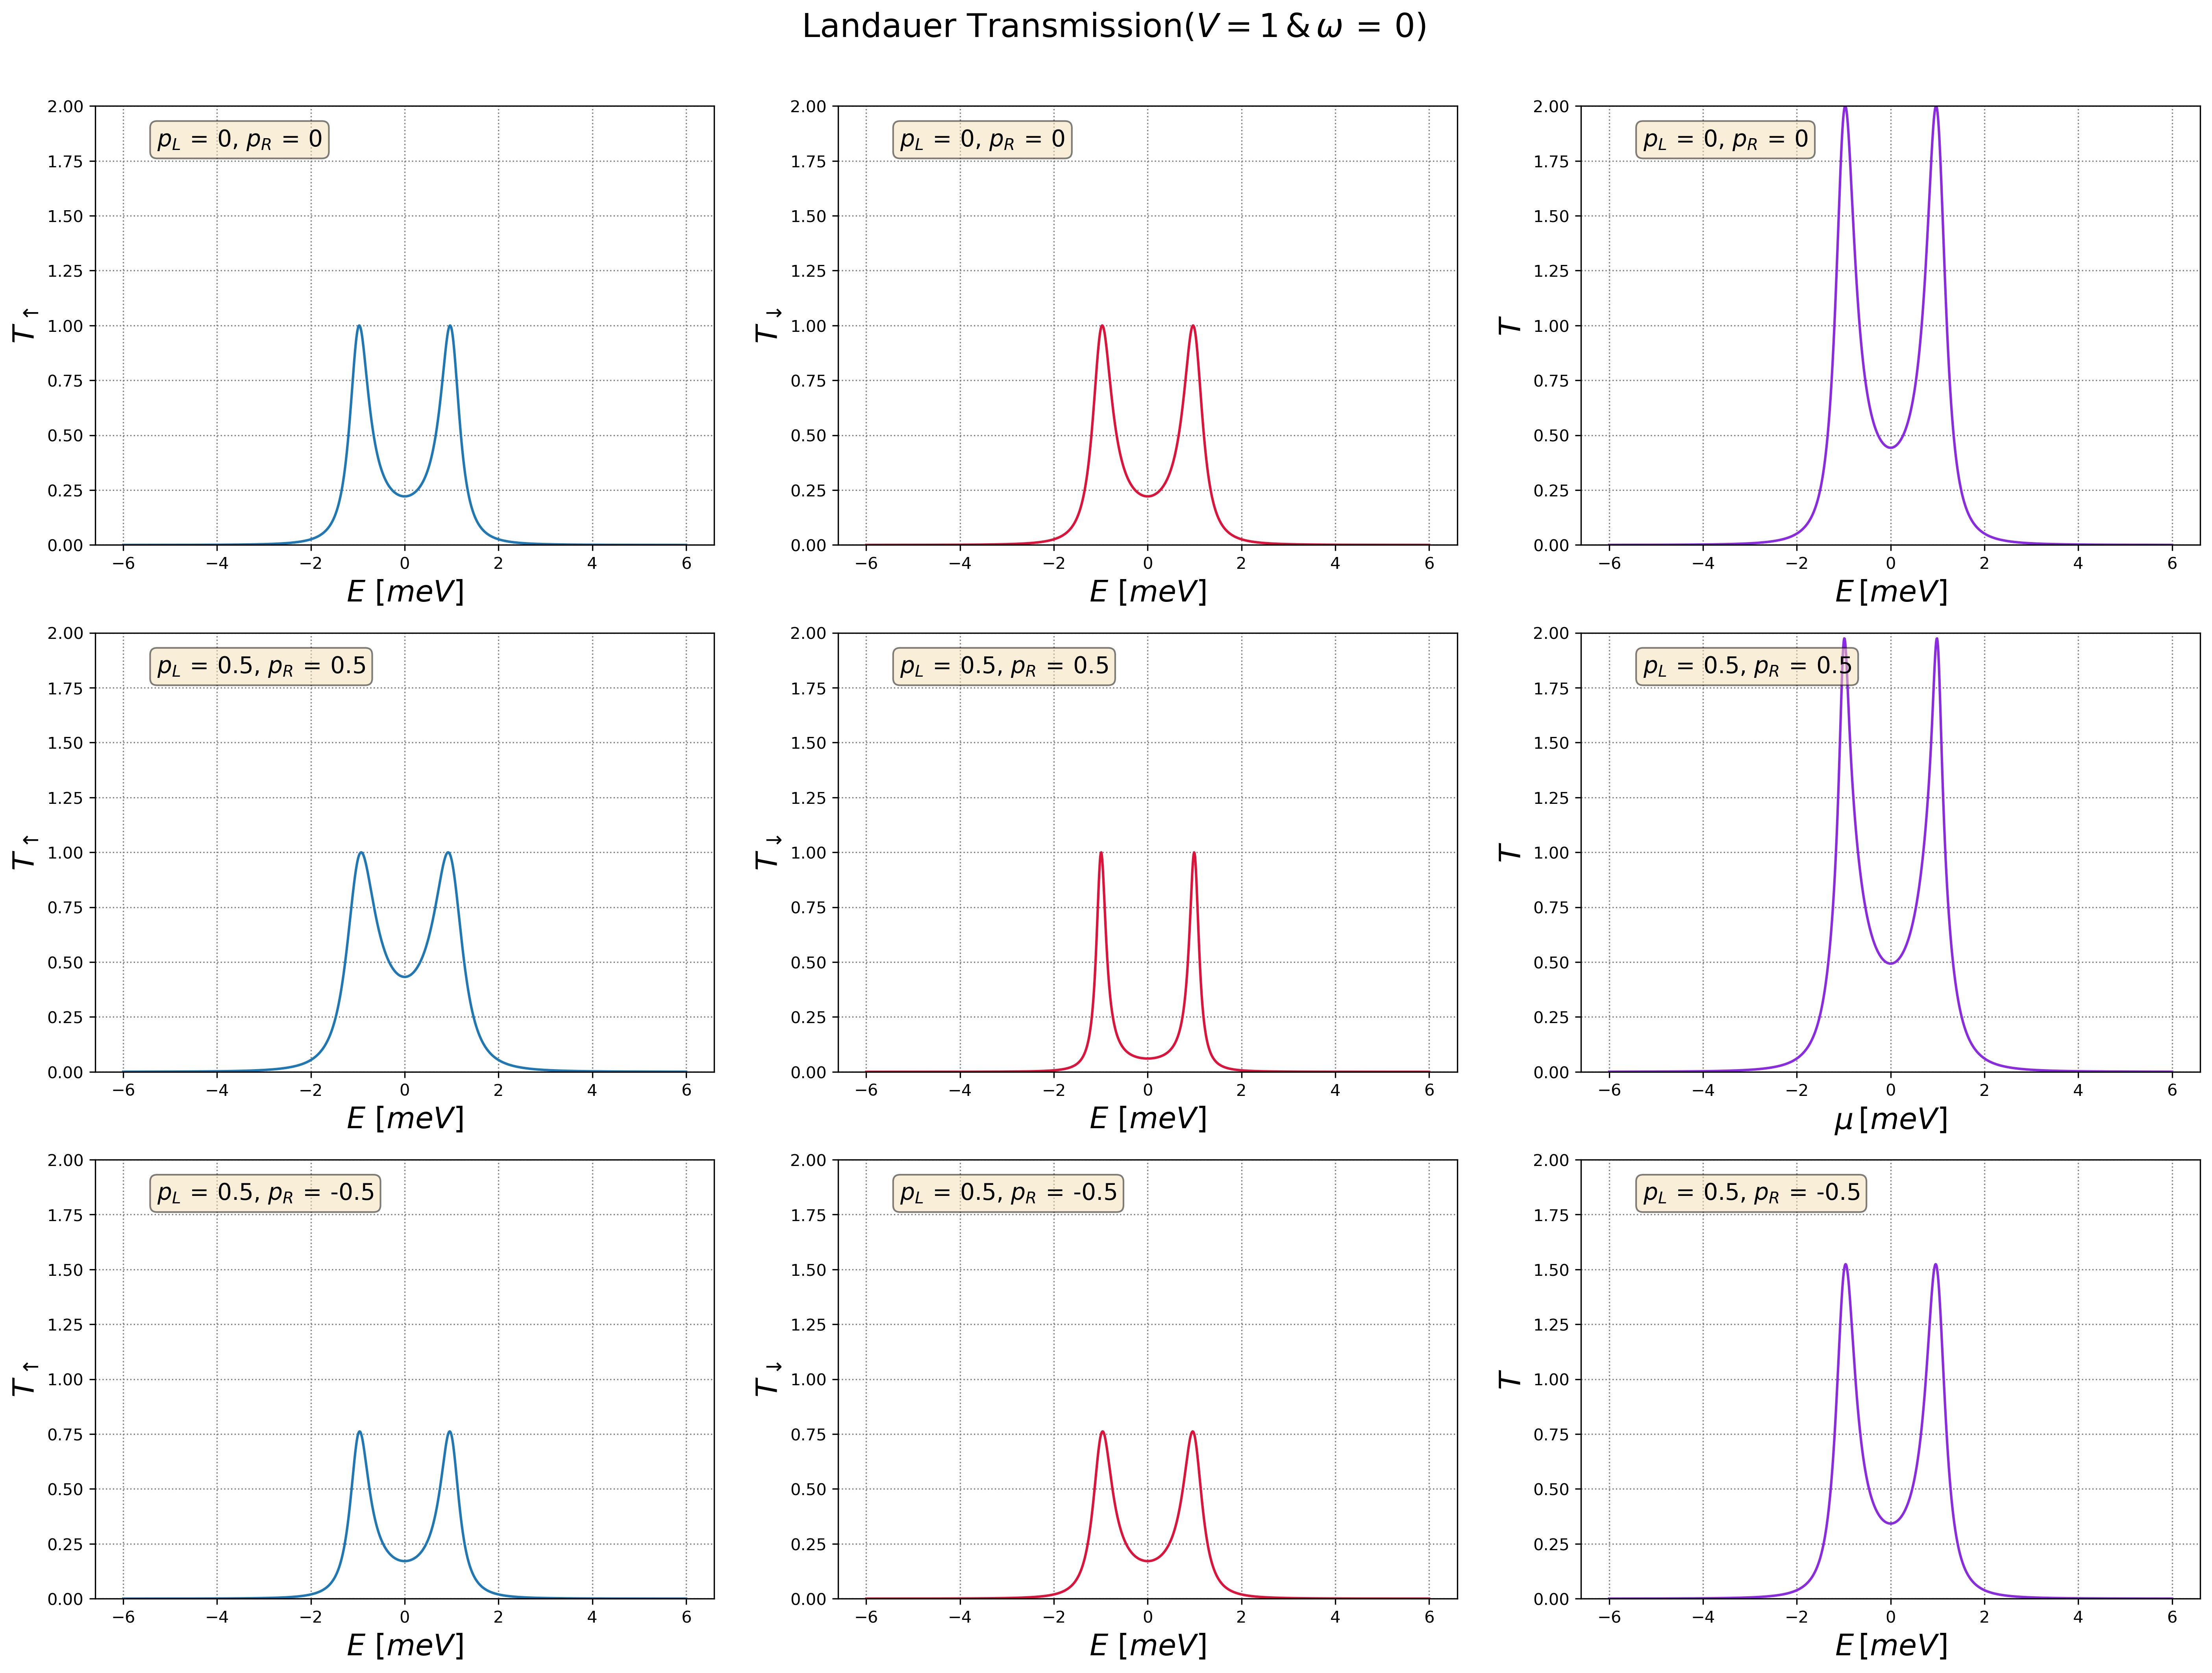

In [13]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('transmission_1.jpg')

## Case 2: $V=3$ and for different polarization configurations

In [14]:
# Hopping
v = 3

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 3.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 3.+0.j]
 [3.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 3.+0.j 0.+0.j 0.+0.j]]


In [15]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [16]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [17]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


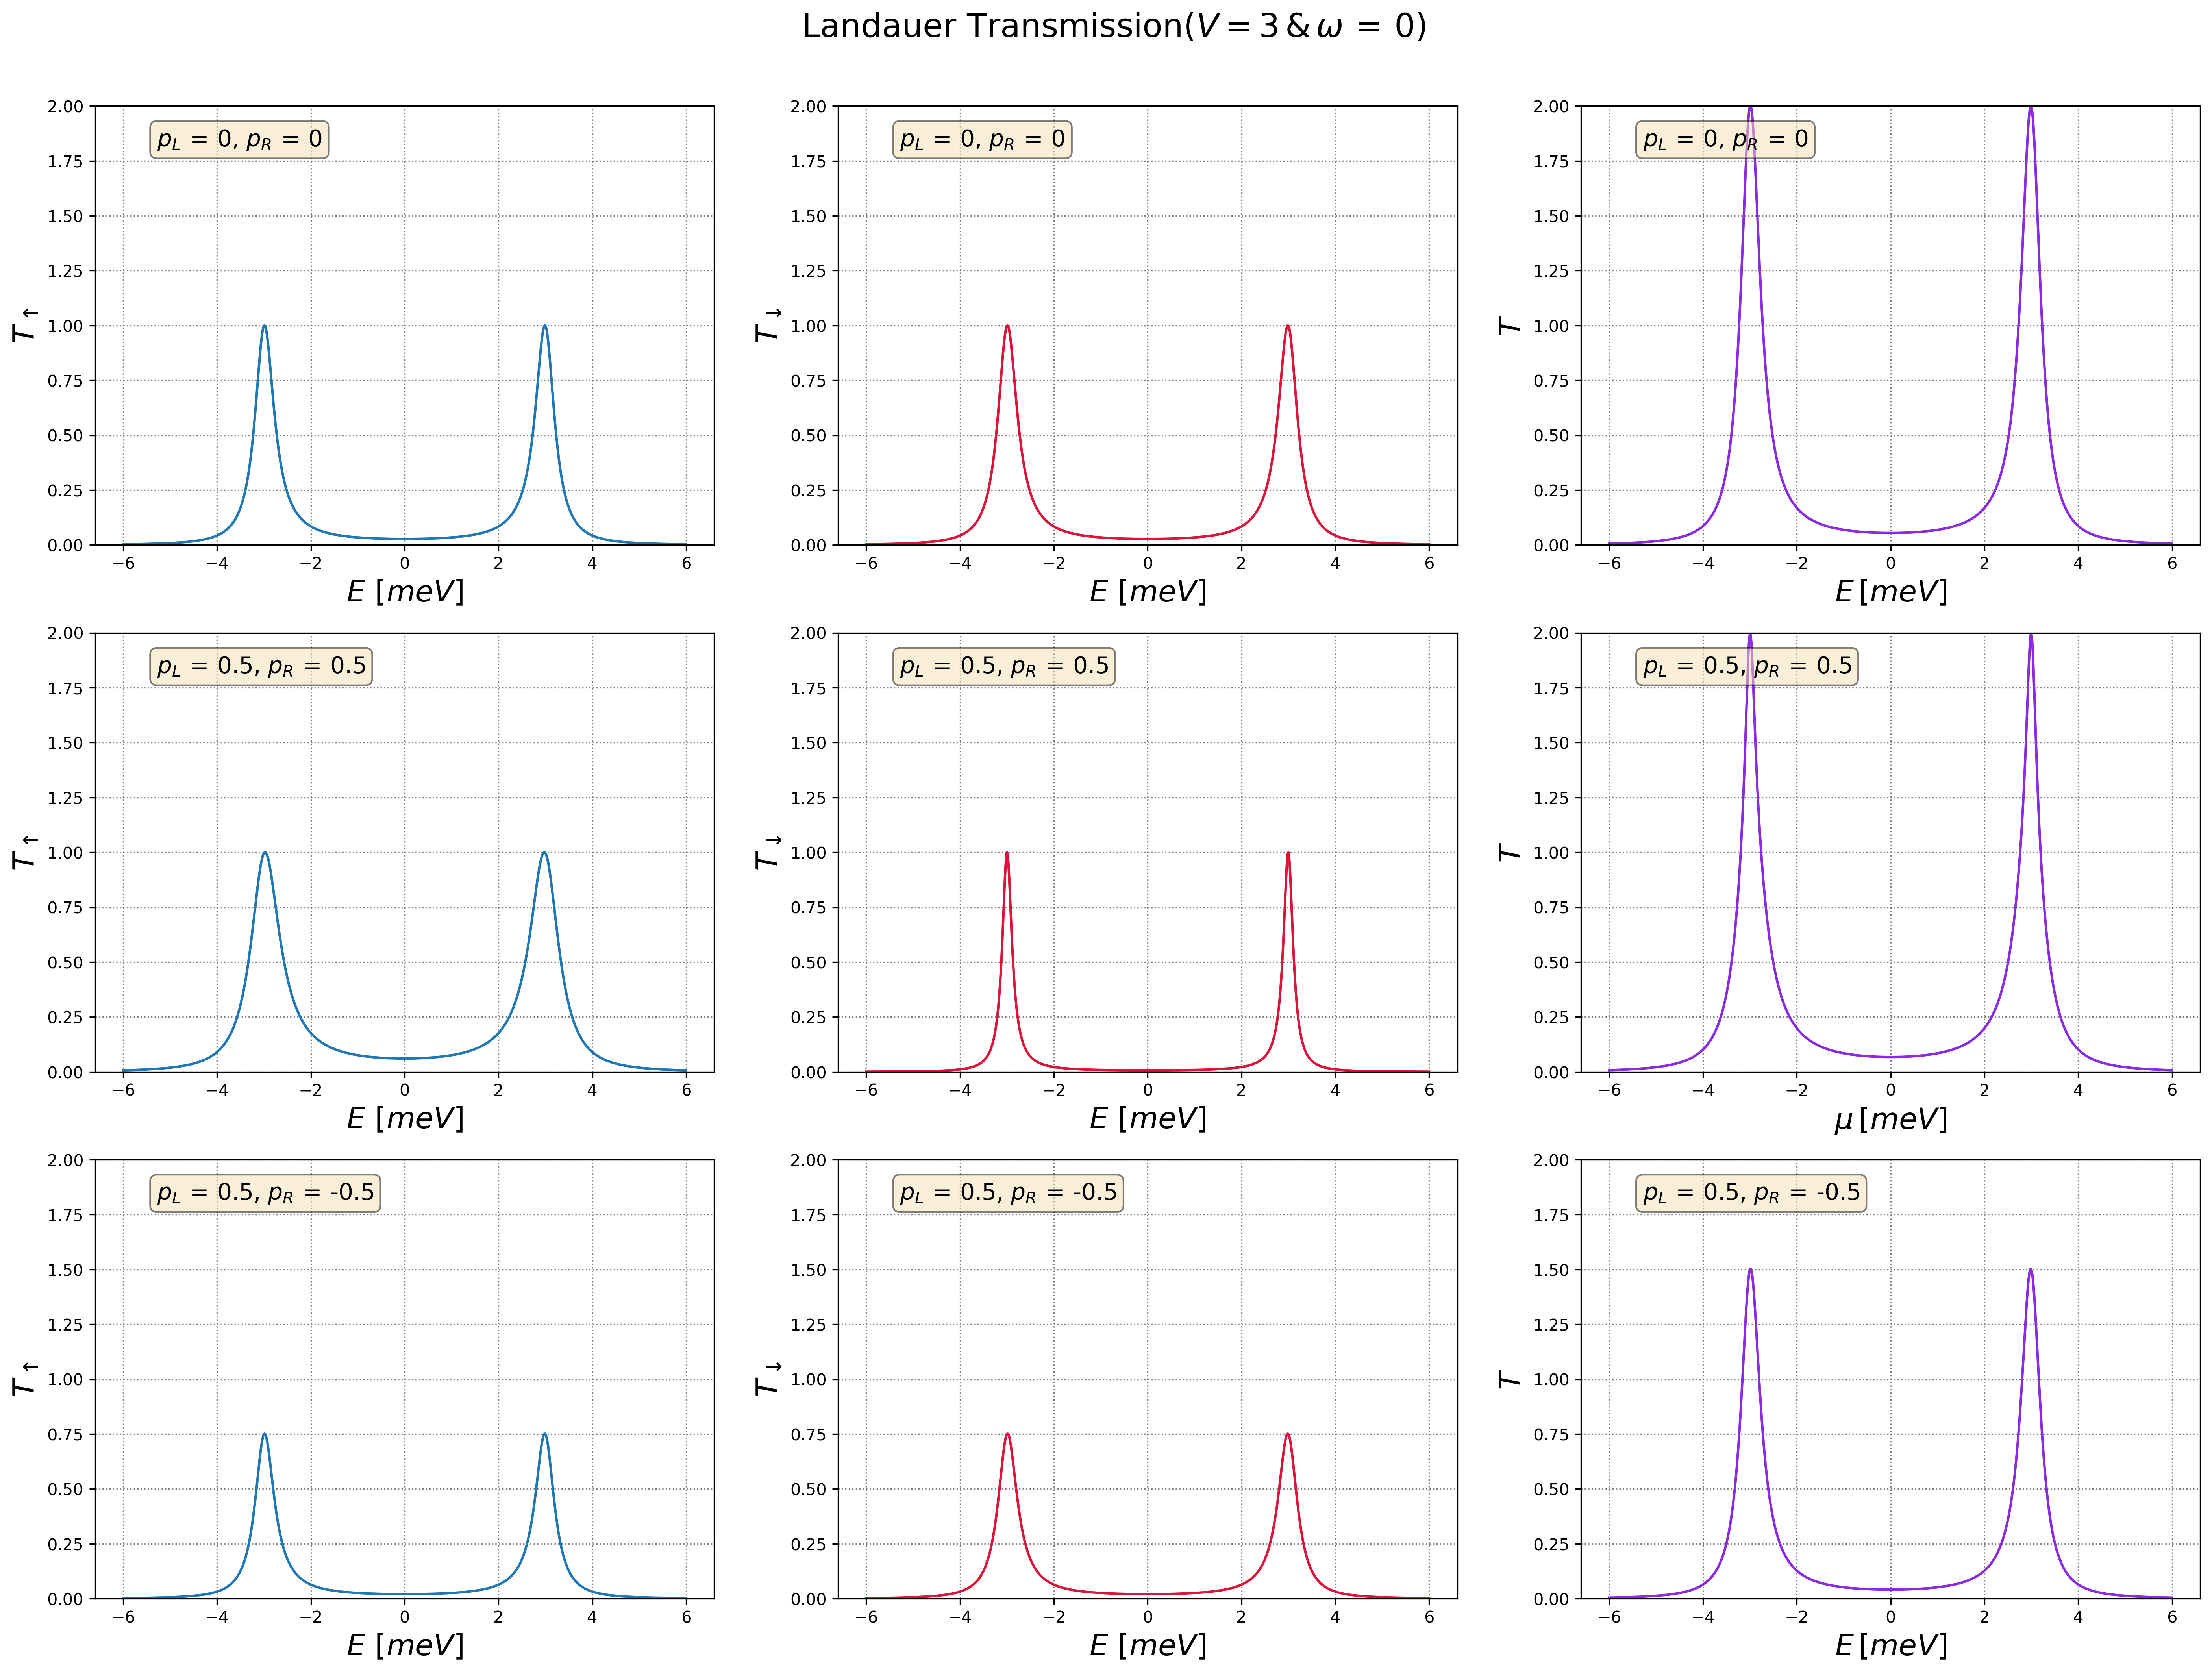

In [18]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('transmission_2.jpg')

## Case 3: $V=4$ and for different polarization configurations

In [19]:
#Energy axis

energy_axis = np.arange(-10, 10 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

Energy axis is [-10.    -9.99  -9.98 ...   9.98   9.99  10.  ] meV


In [20]:
# Hopping
v = 4

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 4.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 4.+0.j]
 [4.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 4.+0.j 0.+0.j 0.+0.j]]


In [21]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [22]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [23]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


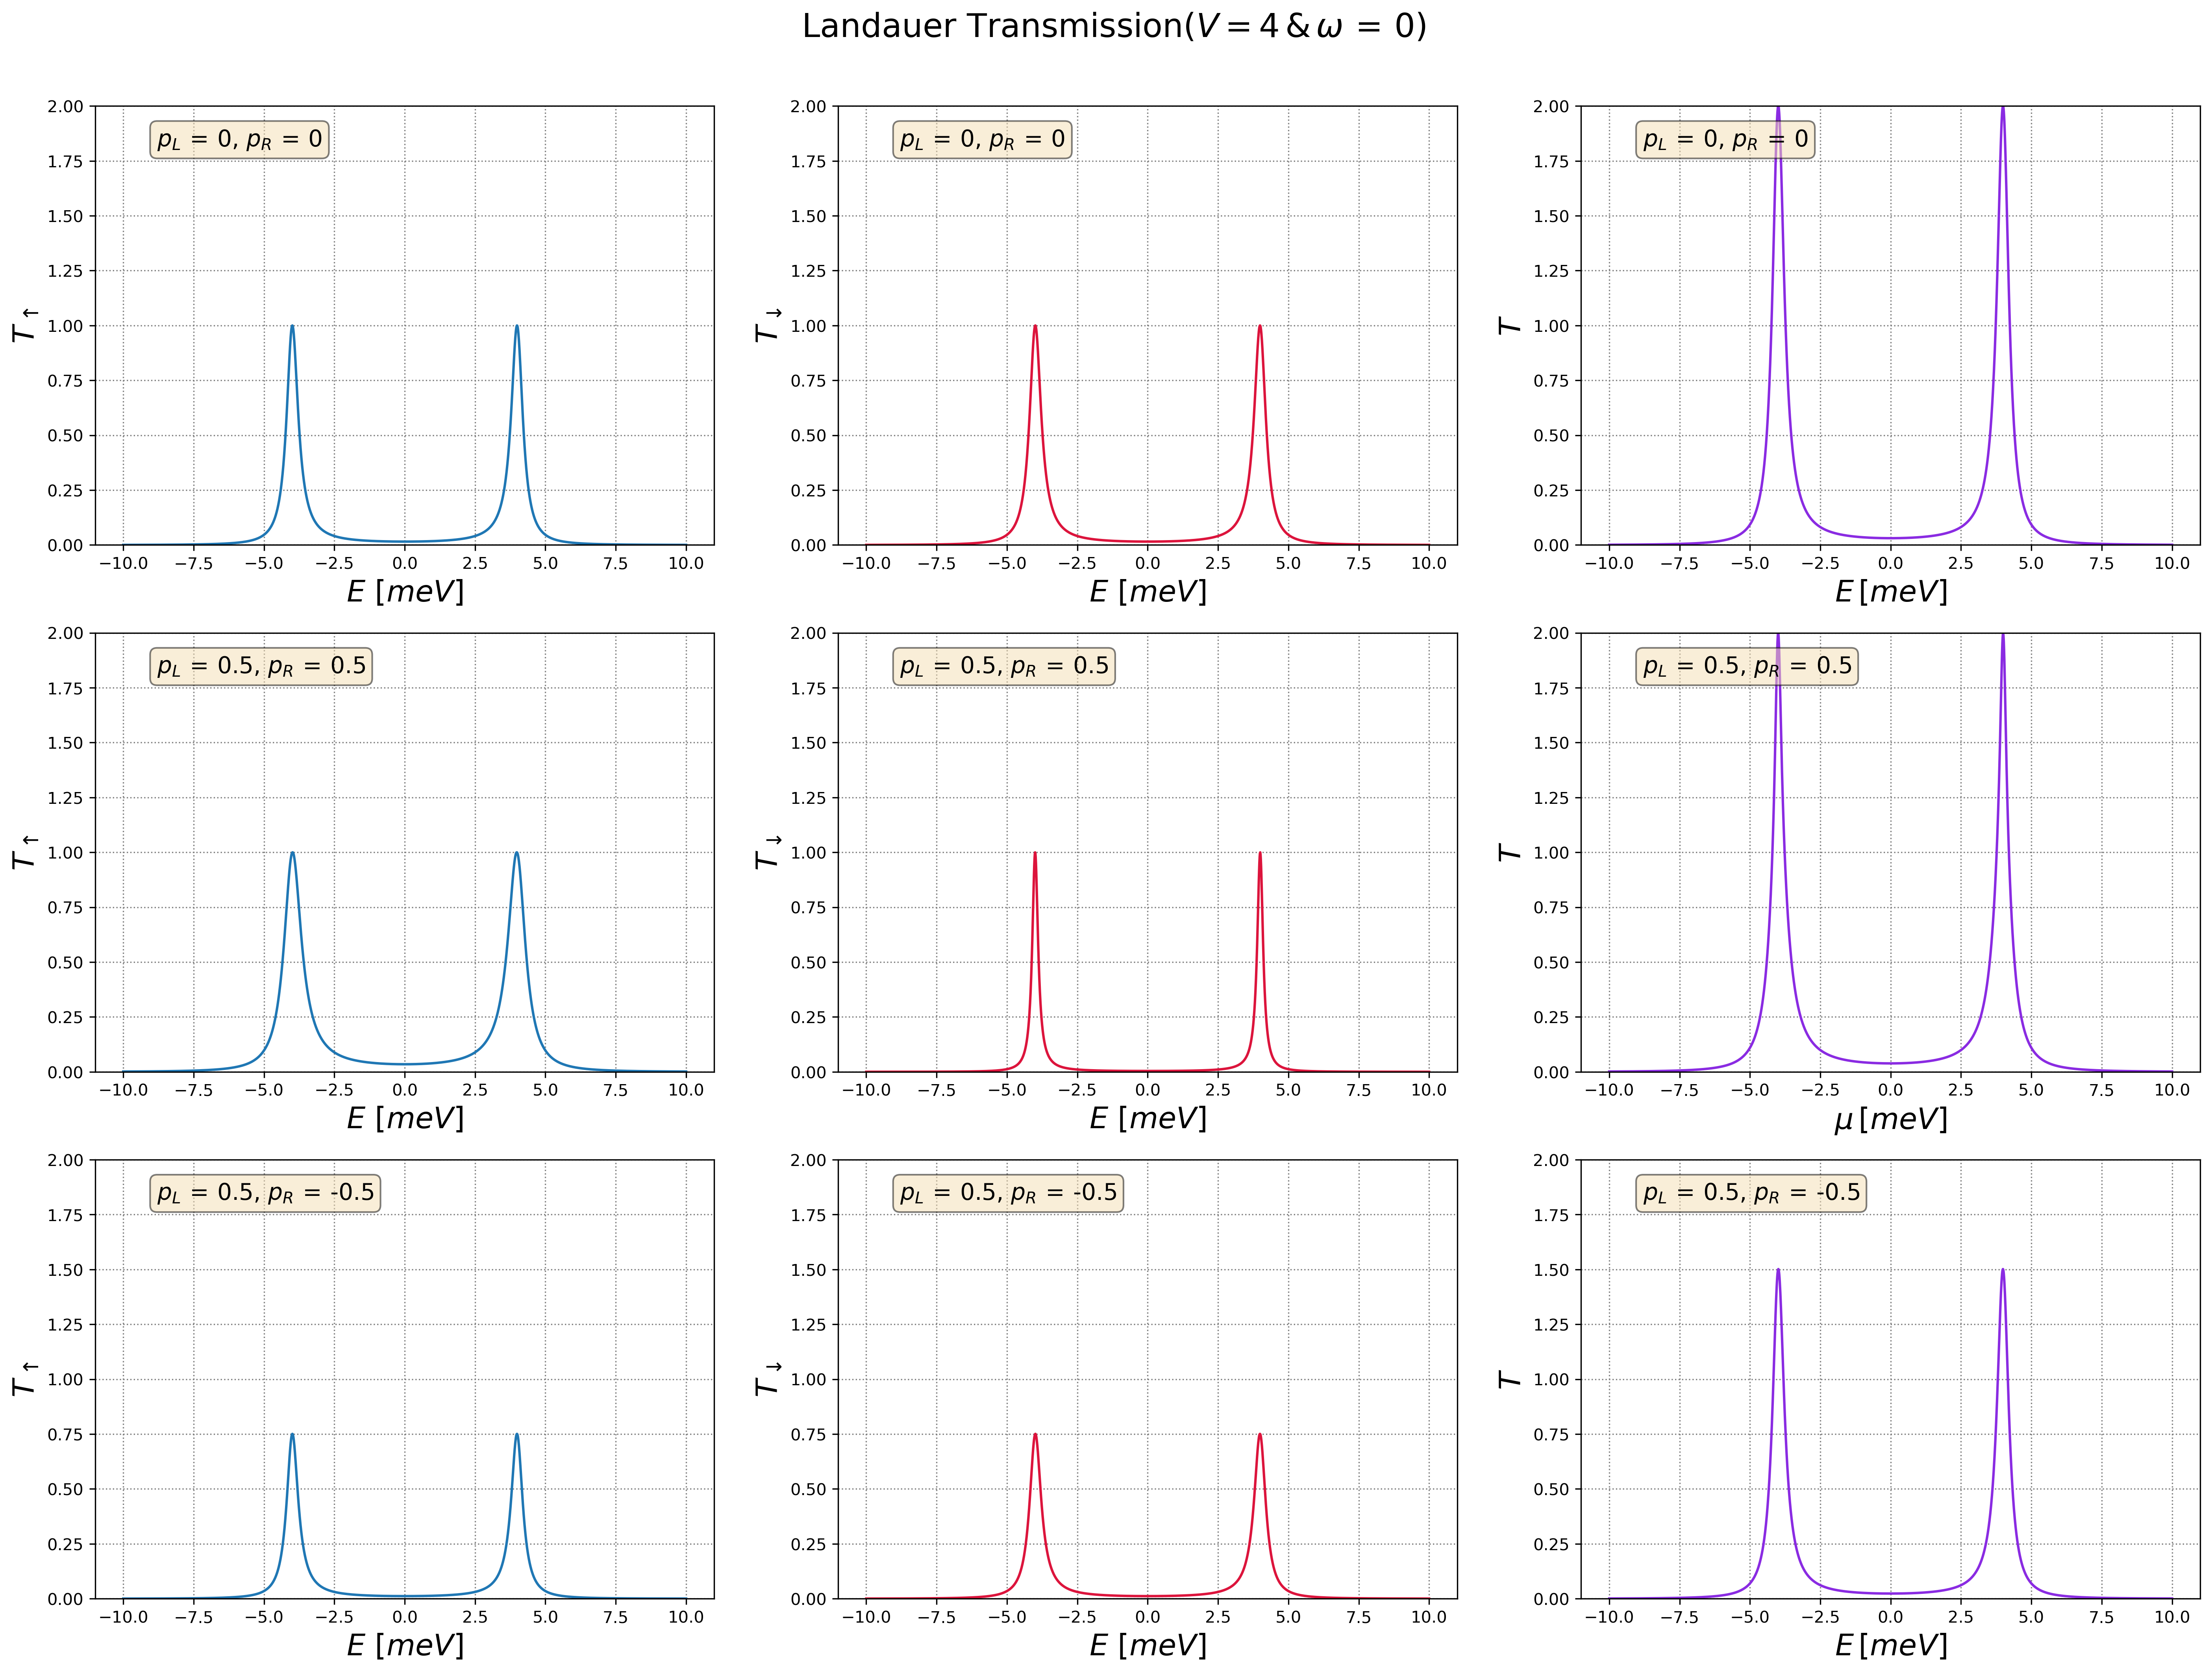

In [24]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('transmission_3.jpg')

# Varying the Hopping $\omega$:

**Fixed parameter**

$V\,=\,\,1\,meV$

In [25]:
#Energy axis

energy_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 1 #meV
print("The width is:",gamma,"meV")

#Site energies:
e_01 = 0 #meV
e_02 = 0 #meV
e_11 = 2 #meV
e_12 = 2 #meV

#Hopping parameter:
v = 1


Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV
The width is: 1 meV


## Reference case:

We have $\omega=0$. Additionally, if $p_{L(R)}=0$ we have the same width (i.e. same particle lifetime) per spin channel! 

Additional, we include the different polarization configurations

In [41]:
#Hopping
om = 0.5 #meV

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies to be renormalized are:", \
#       e_ren_1," meV and",e_ren_2," meV")

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [42]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [43]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [44]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:118: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


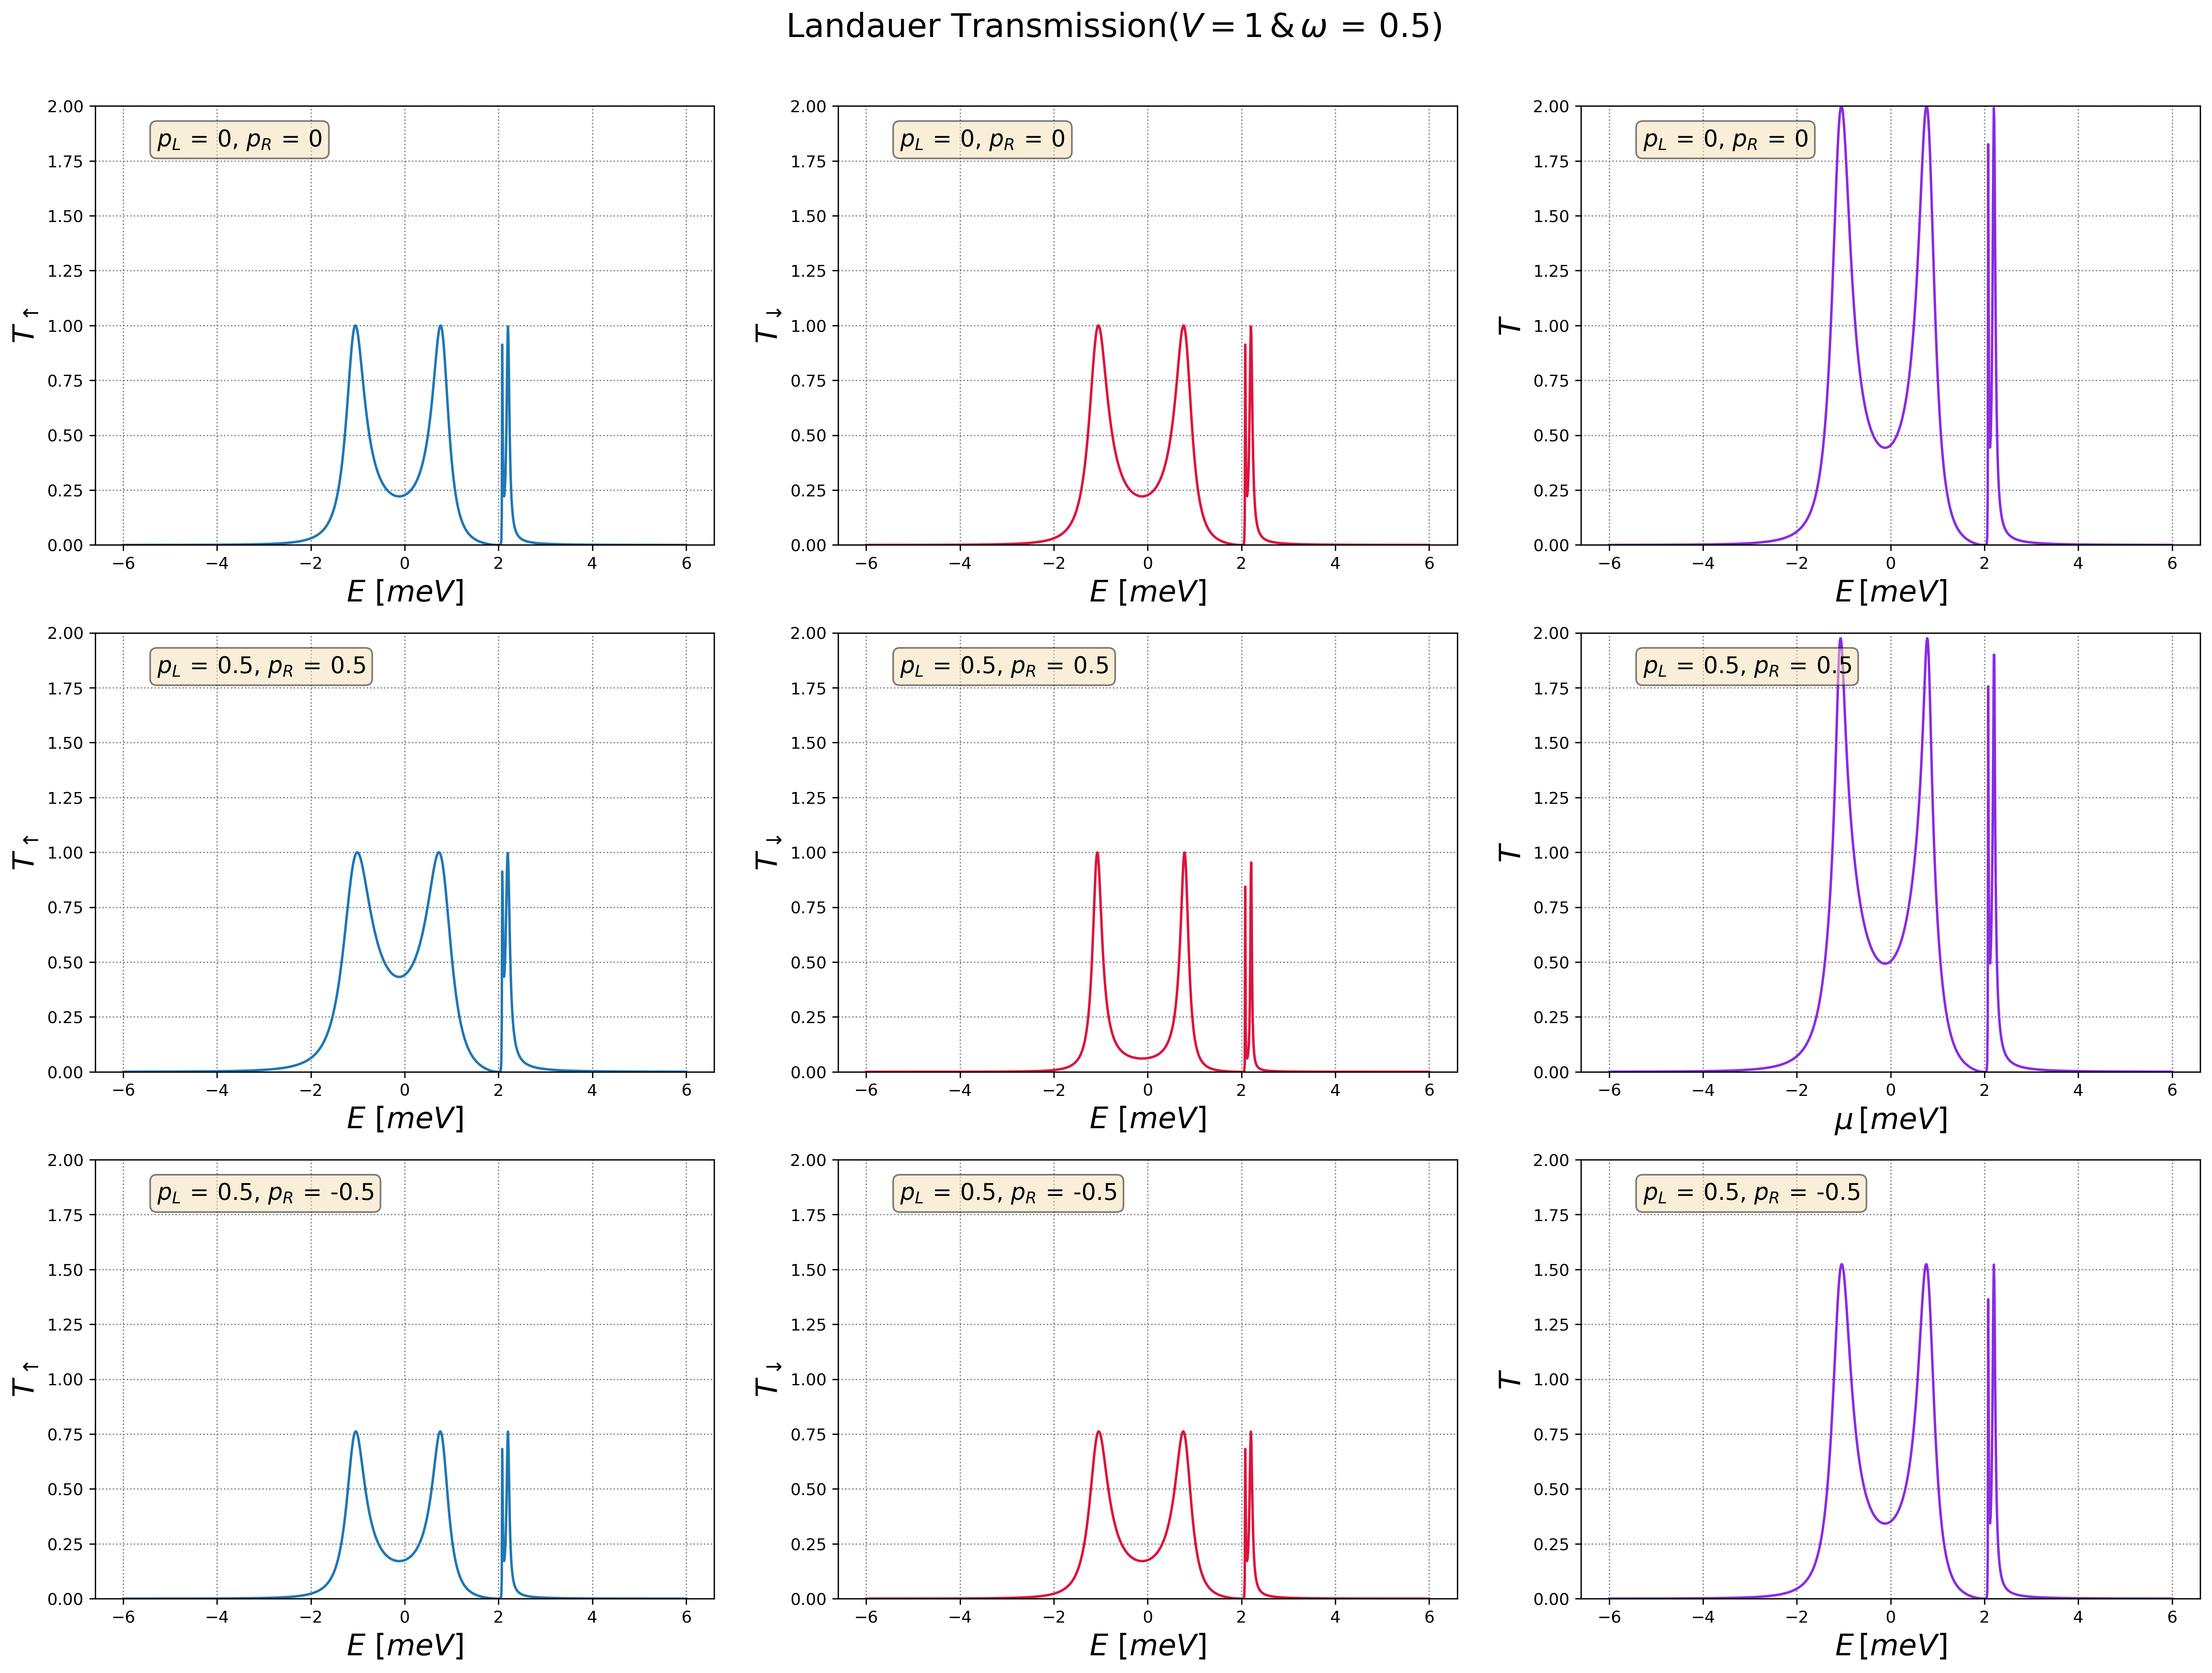

In [45]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('Transmission_4.jpg')

## Case 1: $\omega=1$ and for different polarization configurations

In [46]:
#Hopping
om = 1 #meV

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies to be renormalized are:", \
#       e_ren_1," meV and",e_ren_2," meV")

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [47]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [48]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [49]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


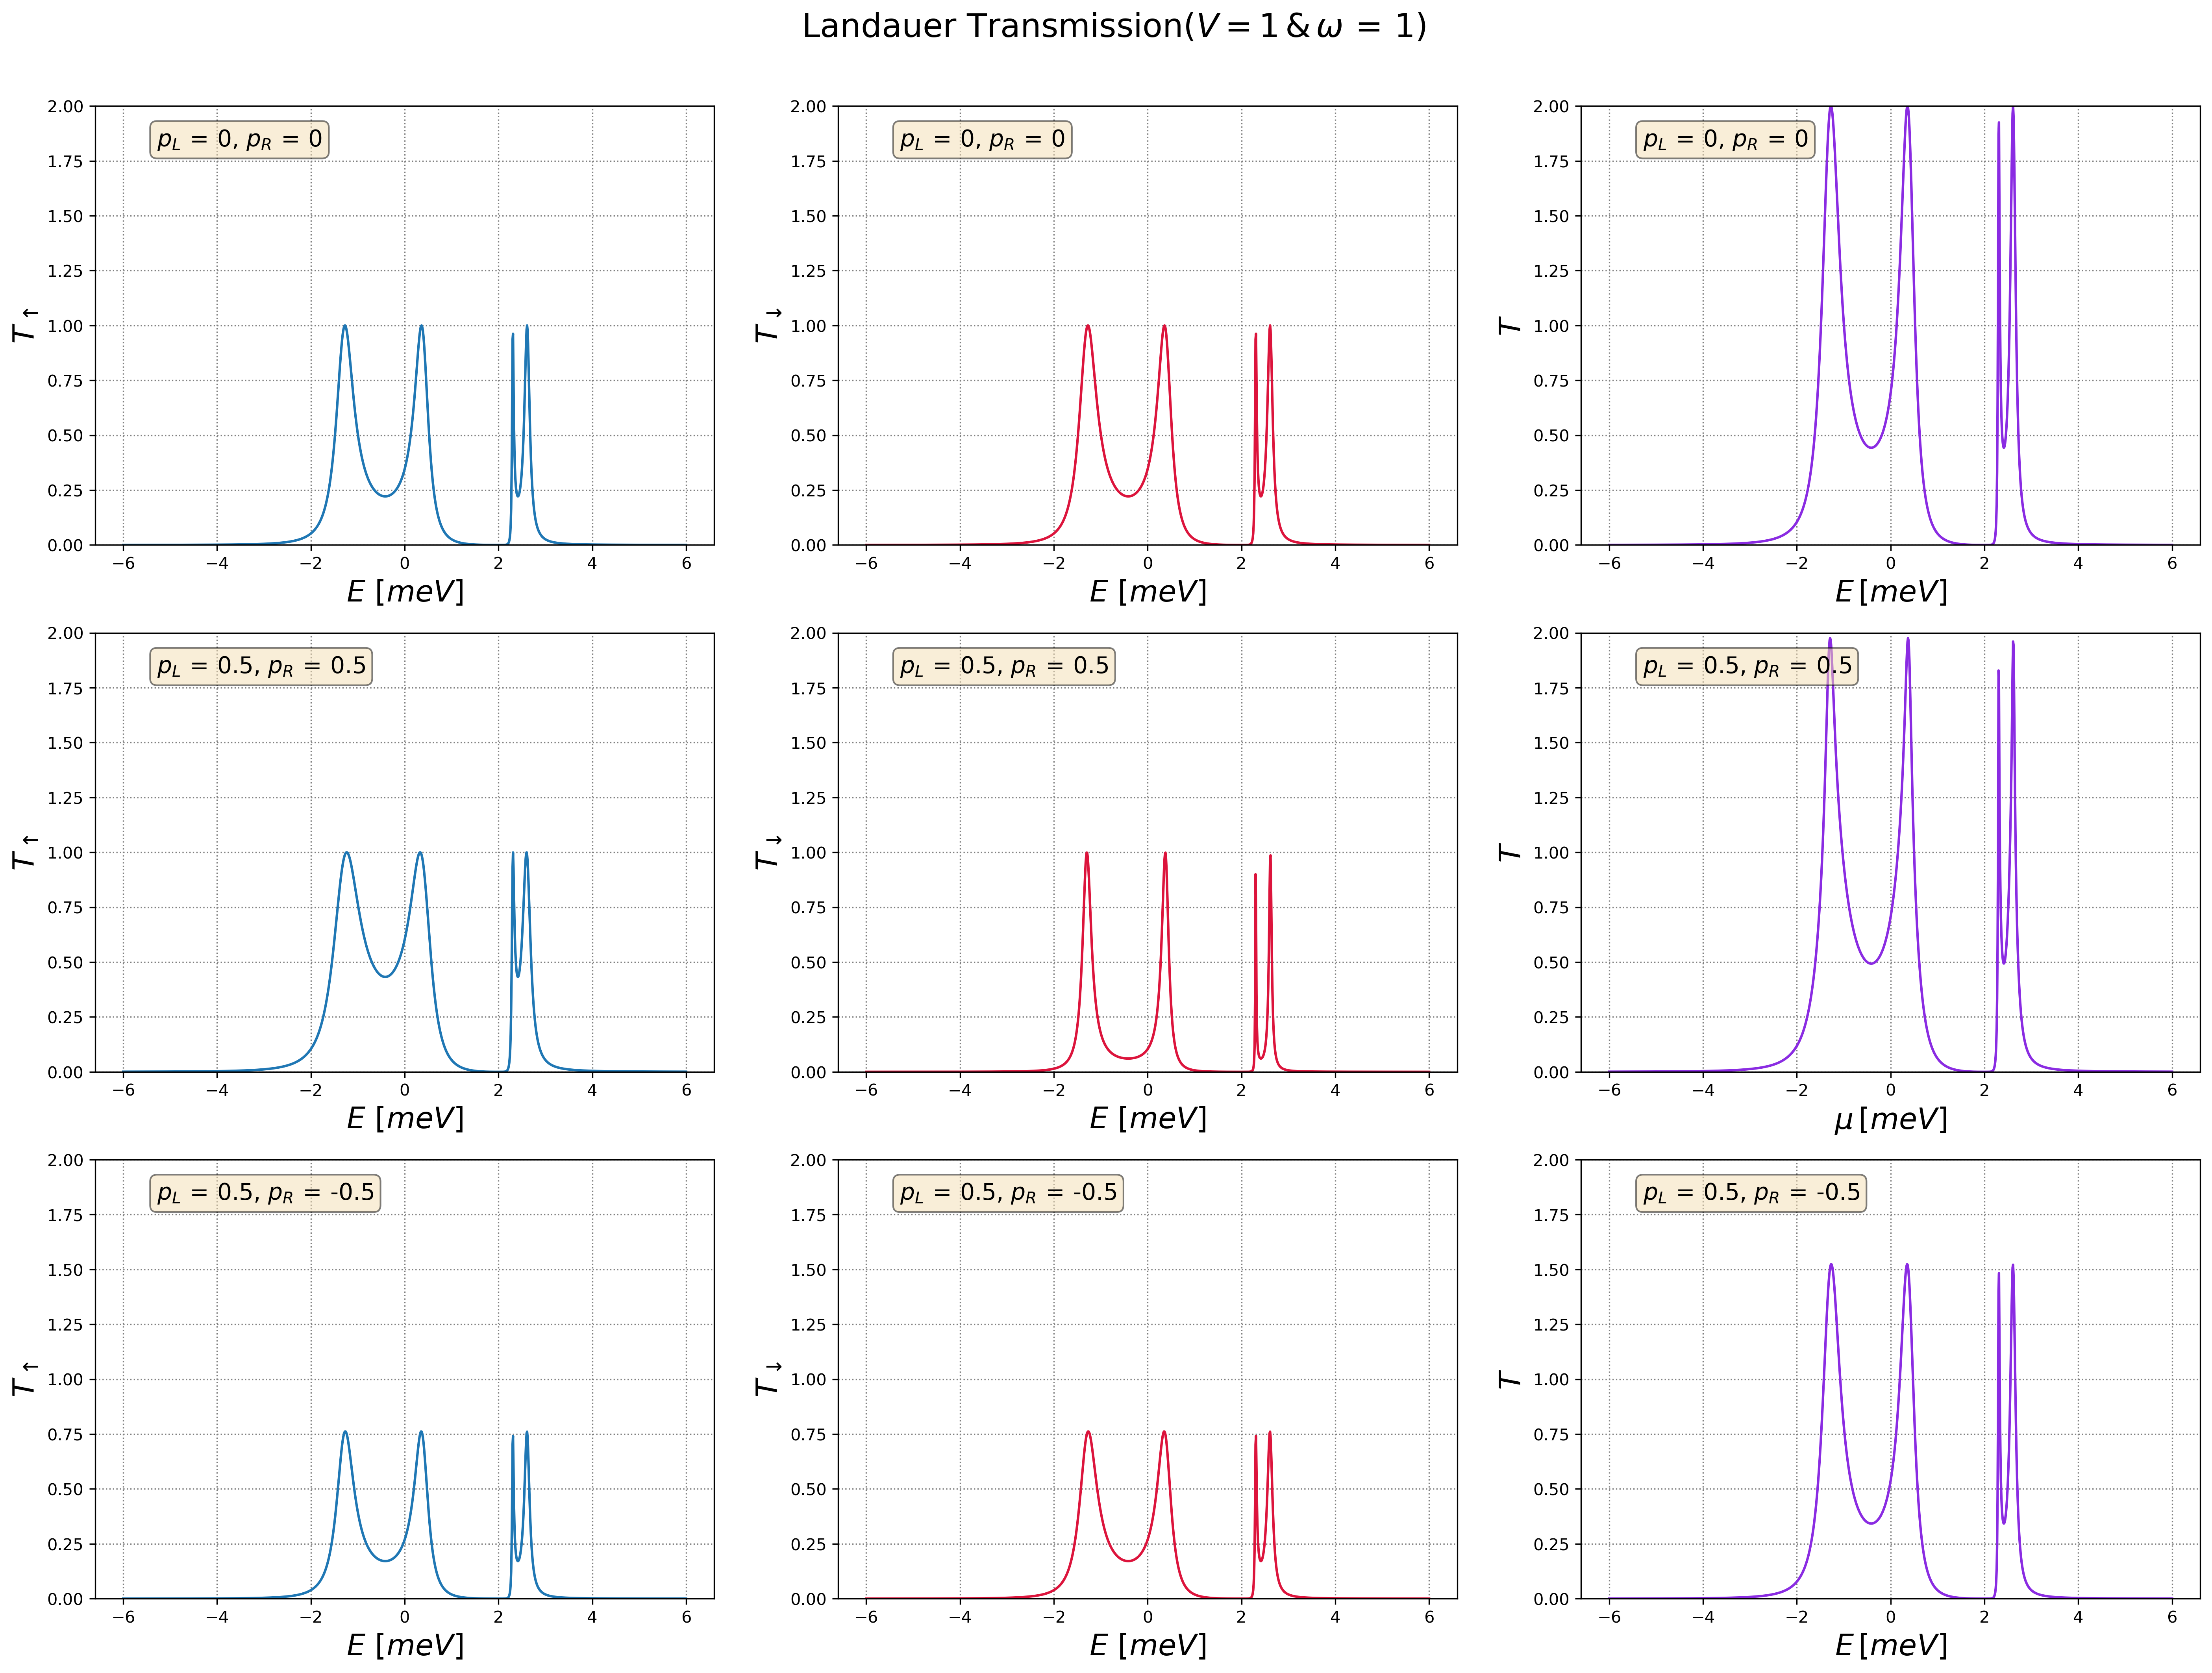

In [50]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('transmission_5.jpg')

## Case 2: $\omega=2$ and for different polarization configurations

In [51]:
#Hopping
om = 2 #meV

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies to be renormalized are:", \
#       e_ren_1," meV and",e_ren_2," meV")

#Definition of the Hamiltonian 

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[0,0,v,0],[0,0,0,v],[v,0,0,0],[0,v,0,0]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]


In [52]:
#POLARIZATION p_L = p_R = 0
p_L = 0
p_R = 0

#Transmission axis

transmission_u = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [53]:
#POLARIZATION UP-UP
p_L_1 = 0.5
p_R_1 = 0.5

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


In [54]:
#POLARIZATION UP-DOWN
p_L_2 = 0.5
p_R_2 = -0.5

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_2, p_R_2)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:119: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


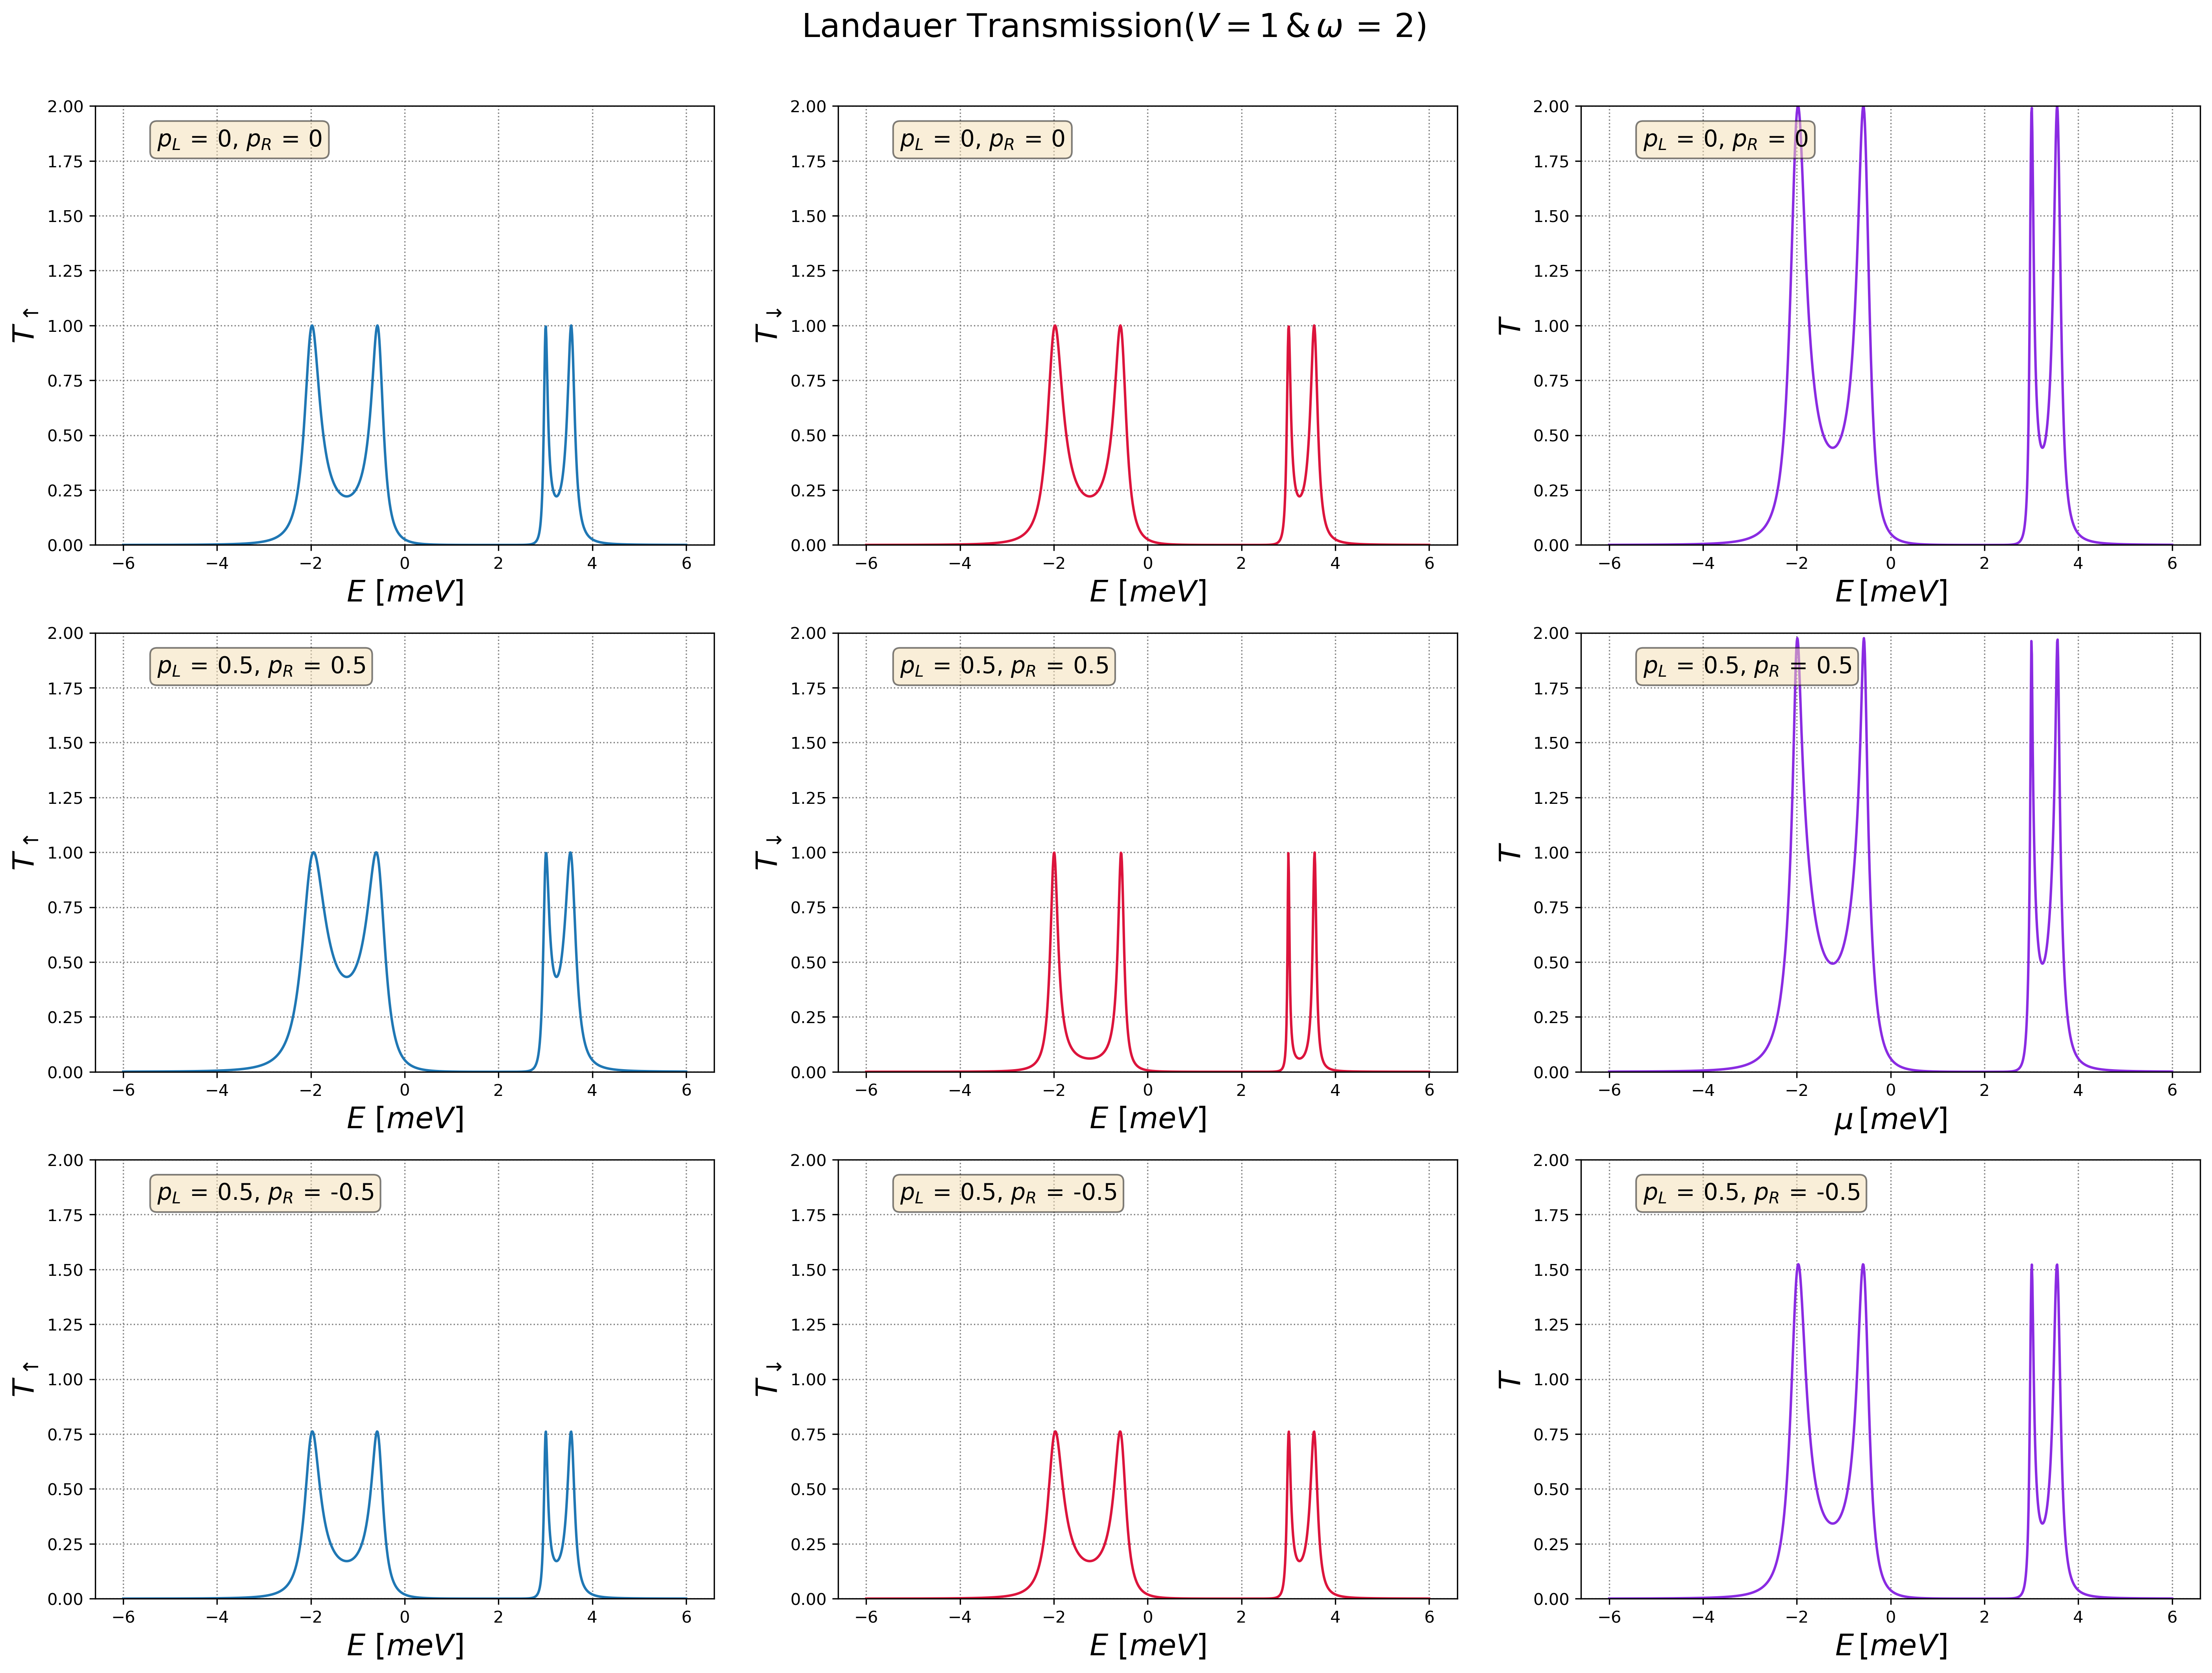

In [55]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(23, 16), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(3, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 1])
ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, transmission_u, "#1f77b4", linestyle="-")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, transmission_d, "#DC143C", linestyle="-")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, transmission_u + transmission_d, "#8A2BE2")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
ax4.plot(energy_axis, transmission_u_1, "#1f77b4", linestyle="-")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
ax5.plot(energy_axis, transmission_d_1, "#DC143C", linestyle="-")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
ax6.plot(energy_axis, transmission_u_1 + transmission_d_1, "#8A2BE2")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax6.legend( loc='upper right')

# UP - UP

ax7.grid(linestyle=':', color='grey')
ax7.plot(energy_axis, transmission_u_2, "#1f77b4", linestyle="-")
ax7.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax7.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax7.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax7.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax7.legend( loc='upper right')

#Seebeck no spin accumulation Plot
ax8.grid(linestyle=':', color='grey')
ax8.plot(energy_axis, transmission_d_2, "#DC143C", linestyle="-")
ax8.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax8.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax8.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax8.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax8.legend( loc='upper right')

#Seebeck spin accumulation Plot:
ax9.grid(linestyle=':', color='grey')
ax9.plot(energy_axis, transmission_u_2 + transmission_d_2, "#8A2BE2")
ax9.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax9.set_ylabel(r"$T$",fontsize=18)
ax9.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_2)+", "r"$p_{R}\,=\,$"+str(p_R_2), transform=ax9.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
#ax9.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  
ax7.set_ylim(0, 2)  
ax8.set_ylim(0, 2)   
ax9.set_ylim(0, 2)  


# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($V=$"+str(v)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

fig.savefig('transmission_6.jpg')

# Conclusion:

$V$ controla la amplitud maxima del Landuer Transmission y ademas controla la distancia entre los picos maximos de la funcion.

$\omega$ controla la aparicion de valores nulos en la funcion, si $\omega=0$, no hay valores nulos. Siempre cerca del valor nulo se presenta una cambio brusco de valor nulo a valor maximo o viceversa.

Ademas, a medida que $\omega>>V$ la funcion tiende a hacerce tan pequeña que parece que no hubiera transmission, pero si hay, aunque sea un valor muy pero muy pequeño, pero no nulo.